### PART 1: Importing Libraries

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


### PART 2: Read CSV

In [87]:
df = pd.read_csv("JSWSTEEL.csv")
print("Shape: ",df.shape)
print("\nFeatures Names: ",df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape:  (3994, 15)

Features Names:  ['Date', 'Symbol', 'Series', 'Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume', 'Turnover', 'Trades', 'Deliverable Volume', '%Deliverble']

First 5 rows:


,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2005-03-23,JSWSTL,EQ,10.00,455.00,458.50,383.60,386.9,390.15,419.86,2087710,8.765375e+13,NaN,382057,0.1830
1,2005-03-24,JSWSTL,EQ,390.15,392.85,398.50,357.50,371.8,369.20,372.01,1226479,4.562638e+13,NaN,232172,0.1893
2,2005-03-28,JSWSTL,EQ,369.20,376.70,394.05,375.00,380.0,378.85,383.64,1235794,4.741048e+13,NaN,263415,0.2132
3,2005-03-29,JSWSTL,EQ,378.85,382.90,383.80,363.25,369.1,368.05,375.26,624072,2.341915e+13,NaN,198916,0.3187
4,2005-03-30,JSWSTL,EQ,368.05,367.00,371.90,360.05,362.7,362.15,365.13,466349,1.702775e+13,NaN,159641,0.3423


### PART 3: Removing Duplicates

In [88]:
print(" Check and Remove Duplicates")
dups = df.duplicated().sum()
print(f"Duplicate rows found: {dups}")
if dups > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

 Check and Remove Duplicates
Duplicate rows found: 0
No duplicates found.


### PART 4: Sorting the Dataframe

In [89]:
df = df.sort_values("Date").reset_index(drop=True)

### PART 5: Defining Numeric Datafarame

In [90]:
numeric_df = df.iloc[:, 3:-1]
print("Nunmeric Dataframe Shape: ",numeric_df.shape)

Nunmeric Dataframe Shape:  (3994, 11)


### PART 6: Interpolation

In [91]:
print("Null values in each column before interpolation:\n")
print(numeric_df.isnull().sum())

numeric_df = numeric_df.apply(pd.to_numeric,errors='coerce')
numeric_df = numeric_df.interpolate(method="linear", limit_direction="both")
numeric_df = numeric_df.ffill().bfill()
print("\nNull values after interpolation:\n")
print(numeric_df.isnull().sum())


Null values in each column before interpolation:

Prev Close               0
Open                     0
High                     0
Low                      0
Last                     0
Close                    0
VWAP                     0
Volume                   0
Turnover                 0
Trades                1538
Deliverable Volume       0
dtype: int64

Null values after interpolation:

Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Trades                0
Deliverable Volume    0
dtype: int64


In [92]:
numeric_df.head()

,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume
0,10.00,455.00,458.50,383.60,386.9,390.15,419.86,2087710,8.765375e+13,20899.0,382057
1,390.15,392.85,398.50,357.50,371.8,369.20,372.01,1226479,4.562638e+13,20899.0,232172
2,369.20,376.70,394.05,375.00,380.0,378.85,383.64,1235794,4.741048e+13,20899.0,263415
3,378.85,382.90,383.80,363.25,369.1,368.05,375.26,624072,2.341915e+13,20899.0,198916
4,368.05,367.00,371.90,360.05,362.7,362.15,365.13,466349,1.702775e+13,20899.0,159641


In [93]:
print(numeric_df.dtypes)

Prev Close            float64
Open                  float64
High                  float64
Low                   float64
Last                  float64
Close                 float64
VWAP                  float64
Volume                  int64
Turnover              float64
Trades                float64
Deliverable Volume      int64
dtype: object


In [94]:
print(numeric_df.columns)

Index(['Prev Close', 'Open', 'High', 'Low', 'Last', 'Close', 'VWAP', 'Volume',
       'Turnover', 'Trades', 'Deliverable Volume'],
      dtype='str')


In [95]:
feature_names = ['Open', 'High', 'Low', 'Close']
numeric_df = df[feature_names]

target_idx = feature_names.index('Close')

print("Features used:", feature_names)

data = numeric_df.values
num_features = data.shape[1]

print("No. of features:", num_features)
print("Shape:", data.shape)

Features used: ['Open', 'High', 'Low', 'Close']
No. of features: 4
Shape: (3994, 4)


### PART 7: Plotting a feature against date

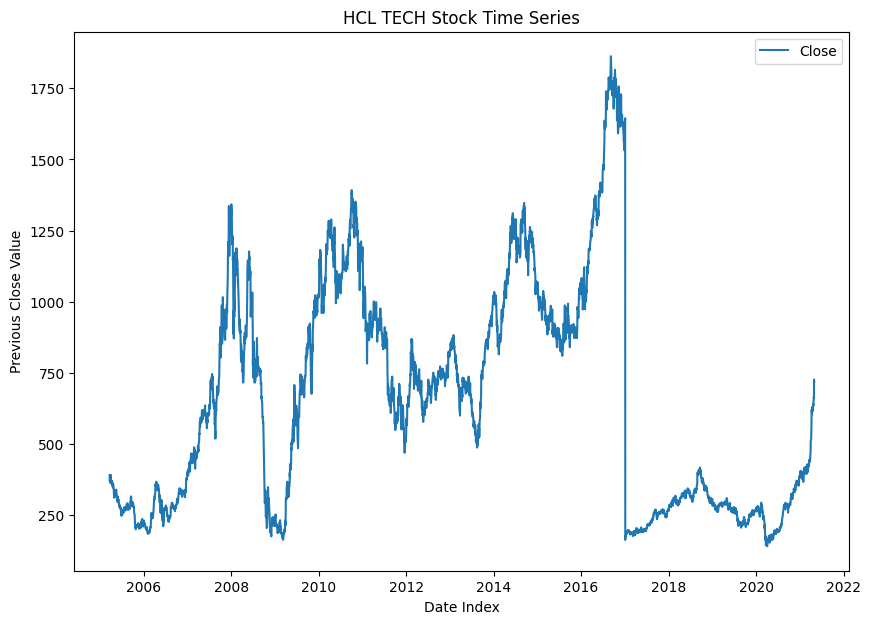

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
df['Date'] = pd.to_datetime(df['Date'])
plt.plot(df['Date'], numeric_df['Close'], label='Close')
plt.title('HCL TECH Stock Time Series')
plt.xlabel('Date Index')
plt.ylabel('Previous Close Value')

plt.legend()
plt.show()

In [97]:
data = numeric_df.values.astype(np.float32)
print("Data Shape:", data.shape)

Data Shape: (3994, 4)


### PART 8: Train-Test-Validation Dataset split

In [98]:
TRAIN_RATIO = 0.8
split_idx = int(len(data) * TRAIN_RATIO)

train_data_temp = data[:split_idx]
test_data = data[split_idx:]

# split train into train and validation sets (80:20)
val_split_idx = int(len(train_data_temp) * 0.8)

train_data = train_data_temp[:val_split_idx]
val_data = train_data_temp[val_split_idx:]

print("Train Dataset Shape: ",train_data.shape)
print("\nValidation Dataset Shape: ",val_data.shape)
print("\nTest Dataset Shape: ",test_data.shape)

Train Dataset Shape:  (2556, 4)

Validation Dataset Shape:  (639, 4)

Test Dataset Shape:  (799, 4)


### PART 9: Normalizing Datasets using 'l2' normalizer

In [99]:
from sklearn.preprocessing import normalize

#axis=0 for column-wise normalization
train_data_norm = normalize(train_data, norm='l2', axis=0)
test_data_norm = normalize(test_data, norm='l2', axis=0)
val_data_norm = normalize(val_data, norm='l2', axis=0)

### PART 10: Creating Time Sequence and Loading Dataset

In [100]:
#input_steps: number of past time steps used as input=10
#output_steps: number of future time steps to predict=5
import numpy as np

INPUT_STEPS = 10
OUTPUT_STEPS = 5
BATCH_SIZE = 32

def create_sequences(data_array, input_steps=INPUT_STEPS, output_steps=OUTPUT_STEPS, overlap=1):
    X, y = [], []
    total_len = len(data_array)

    stride = input_steps - overlap
    if stride <= 0:
        raise ValueError("overlap must be smaller than input_steps")

    for i in range(0, total_len - input_steps - output_steps + 1, stride):
        X.append(data_array[i:i + input_steps])
        y.append(data_array[i + input_steps : i + input_steps + output_steps, target_idx])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [101]:
X_train, y_train = create_sequences(train_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_test, y_test = create_sequences(test_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)
X_val, y_val = create_sequences(val_data_norm, INPUT_STEPS, OUTPUT_STEPS, overlap=8)

print("X_train Shape :", X_train.shape, "| y_train Shape :", y_train.shape)
print("X_test Shape :", X_test.shape, "| y_test Shape :", y_test.shape)
print("X_val Shape :", X_val.shape, "| y_val Shape :", y_val.shape)

X_train Shape : (1271, 10, 4) | y_train Shape : (1271, 5)
X_test Shape : (393, 10, 4) | y_test Shape : (393, 5)
X_val Shape : (313, 10, 4) | y_val Shape : (313, 5)


In [102]:
from torch.utils.data import Dataset
import torch

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [103]:
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
val_dataset = TimeSeriesDataset(X_val, y_val)

In [104]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

### PART 11: Defining LSTM Neural Network Model

In [105]:
import torch.nn as nn

class LSTMForecaster(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 🔥 Input features = 4 (Open, High, Low, Close)
        self.lstm = nn.LSTM(input_size=4, hidden_size=32, batch_first=True)
        
        # 🔥 Output = 5 future values (Close only)
        self.fc = nn.Linear(32, 5)

    def forward(self, x):
        out, _ = self.lstm(x)
        
        # last timestep
        out = out[:, -1, :]
        
        out = self.fc(out)
        
        return out   # shape: (batch_size, 5)

In [106]:
import torch

model = LSTMForecaster().to(device)

lr = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion_MSE = nn.MSELoss()
criterion_MAE = nn.L1Loss()

def RMSELoss(y_pred, y_true):
    mse = nn.MSELoss()(y_pred, y_true)
    rmse = torch.sqrt(mse)
    return rmse

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=10
)

In [107]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = criterion(preds, y_batch.squeeze(-1))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    return running_loss / len(loader.dataset)

In [108]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = criterion(preds, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            all_preds.append(preds.cpu())
            all_targets.append(y_batch.cpu())

    avg_loss = running_loss / len(loader.dataset)
    all_preds = torch.cat(all_preds, dim=0).numpy()
    all_targets = torch.cat(all_targets, dim=0).numpy()

    return avg_loss, all_preds, all_targets

### PART 12: Training and Testing the Model

In [109]:
EPOCHS = 200
PATIENCE = 20  # stop if no improvement for 20 epochs
train_losses_MSE = []
val_losses_MSE = []
best_val_loss = float('inf')
epochs_no_improve = 0

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion_MSE, device)
    val_loss, _, _ = evaluate(model, val_loader, criterion_MSE, device)

    train_losses_MSE.append(train_loss)
    val_losses_MSE.append(val_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

    # Early stopping logic
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0

        torch.save(model.state_dict(), "best_model.pt")
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE:
        print(f"Early stopping triggered at epoch {epoch+1}")
        break

Epoch [1/200] | Train Loss: 0.026621 | Val Loss: 0.026492
Epoch [2/200] | Train Loss: 0.019759 | Val Loss: 0.019613
Epoch [3/200] | Train Loss: 0.013684 | Val Loss: 0.013361
Epoch [4/200] | Train Loss: 0.008300 | Val Loss: 0.007852
Epoch [5/200] | Train Loss: 0.003963 | Val Loss: 0.003702
Epoch [6/200] | Train Loss: 0.001301 | Val Loss: 0.001543
Epoch [7/200] | Train Loss: 0.000305 | Val Loss: 0.000840
Epoch [8/200] | Train Loss: 0.000088 | Val Loss: 0.000670
Epoch [9/200] | Train Loss: 0.000058 | Val Loss: 0.000632
Epoch [10/200] | Train Loss: 0.000055 | Val Loss: 0.000619
Epoch [11/200] | Train Loss: 0.000054 | Val Loss: 0.000614
Epoch [12/200] | Train Loss: 0.000054 | Val Loss: 0.000609
Epoch [13/200] | Train Loss: 0.000054 | Val Loss: 0.000609
Epoch [14/200] | Train Loss: 0.000054 | Val Loss: 0.000604
Epoch [15/200] | Train Loss: 0.000053 | Val Loss: 0.000600
Epoch [16/200] | Train Loss: 0.000053 | Val Loss: 0.000596
Epoch [17/200] | Train Loss: 0.000053 | Val Loss: 0.000598
Epoch 

In [110]:
test_loss_MSE, predictions_MSE, targets = evaluate(model, test_loader, criterion_MSE, device)
print("\nFinal Test Loss using MSE:", test_loss_MSE)


Final Test Loss using MSE: 3.839708471750135e-06


In [111]:
test_loss_RMSE, predictions_RMSE, targets1 = evaluate(model, test_loader, RMSELoss, device)
print("\nFinal Test Loss using RMSE:", test_loss_RMSE)


Final Test Loss using RMSE: 0.0017127665067826216


In [112]:
test_loss_MAE, predictions_MAE, targets2= evaluate(model, test_loader, criterion_MAE, device)
print("\nFinal Test Loss using MAE:", test_loss_MAE)


Final Test Loss using MAE: 0.0013495784800300616


### PART 13: Plotting Predicted values vs Target values using different Loss Function

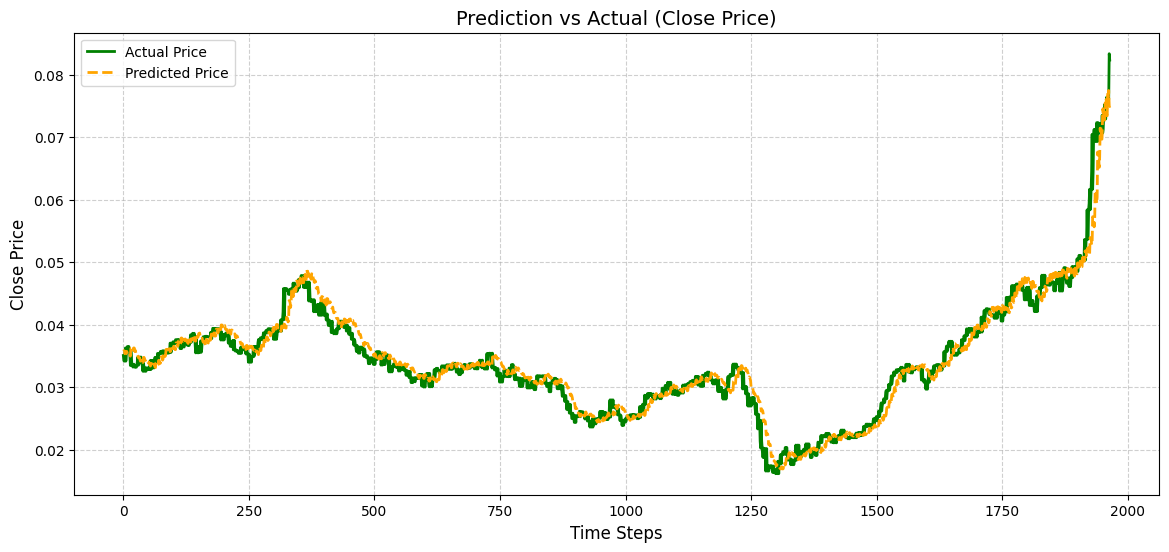

In [114]:
PLOT_FEATURE = "Close"

plt.figure(figsize=(14, 6))

pred_feature = predictions_MSE.reshape(-1)
true_feature = targets.reshape(-1)

plt.plot(true_feature, label="Actual Price", color="green", linewidth=2)
plt.plot(pred_feature, label="Predicted Price", color="orange", linestyle="--", linewidth=2)

plt.title("Prediction vs Actual (Close Price)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

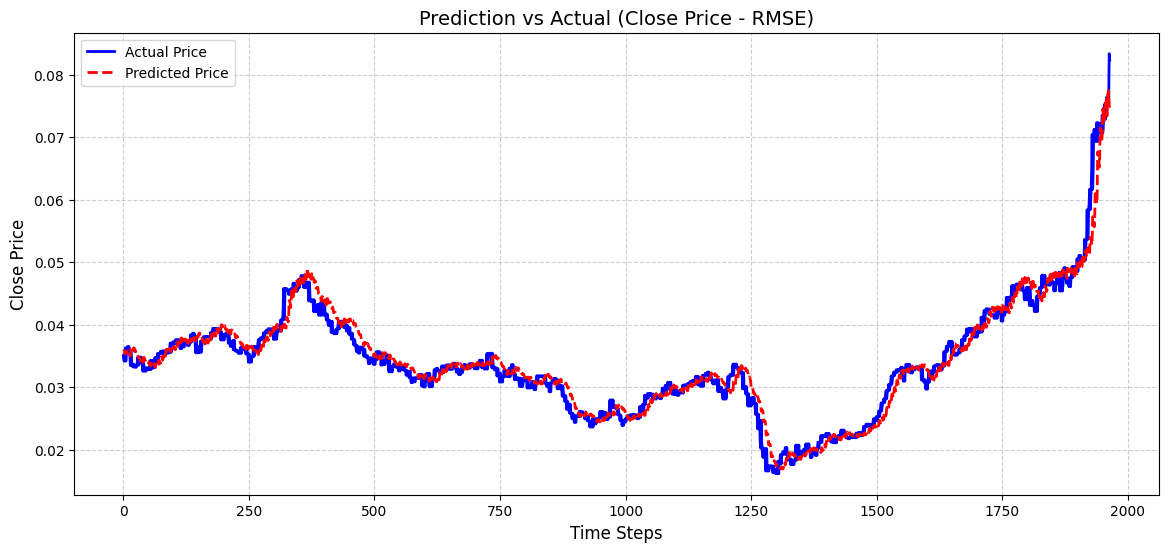

In [116]:
# RMSE (Root Mean Squared Error)

plt.figure(figsize=(14, 6))

pred_feature = predictions_RMSE.reshape(-1)
true_feature = targets1.reshape(-1)

# 🎨 Styled lines
plt.plot(true_feature, label="Actual Price", color="blue", linewidth=2)
plt.plot(pred_feature, label="Predicted Price", color="red", linestyle="--", linewidth=2)

# 🧾 Labels & title
plt.title("Prediction vs Actual (Close Price - RMSE)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

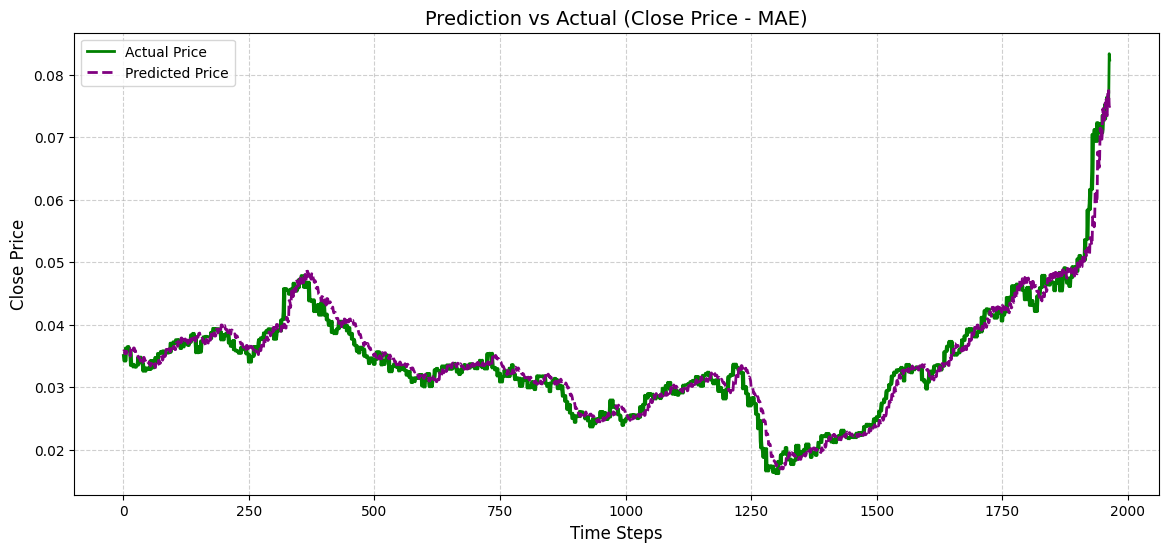

In [118]:
# MAE (Mean Absolute Error)

plt.figure(figsize=(14, 6))

pred_feature = predictions_MAE.reshape(-1)
true_feature = targets2.reshape(-1)

plt.plot(true_feature, label="Actual Price", color="green", linewidth=2)
plt.plot(pred_feature, label="Predicted Price", color="purple", linestyle="--", linewidth=2)

plt.title("Prediction vs Actual (Close Price - MAE)", fontsize=14)
plt.xlabel("Time Steps", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

### PART 14: Plotting Predicted vs Target values of all 11 features for 5 days

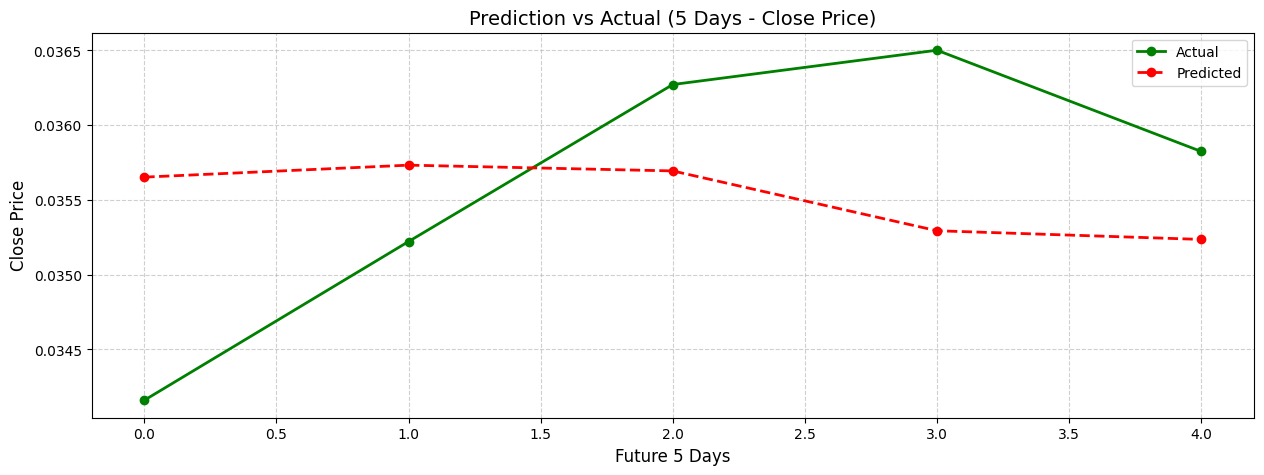

In [120]:
pred_feature = predictions_MSE[1].reshape(-1)
true_feature = targets[1].reshape(-1)

plt.figure(figsize=(15, 5))

# 🎨 Clear styling
plt.plot(true_feature, marker='o', label="Actual", color="green", linewidth=2)
plt.plot(pred_feature, marker='o', label="Predicted", color="red", linestyle='--', linewidth=2)

plt.title("Prediction vs Actual (5 Days - Close Price)", fontsize=14)
plt.xlabel("Future 5 Days", fontsize=12)
plt.ylabel("Close Price", fontsize=12)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

### PART 15: Performance Metrics (MSE, RMSE, and MAE)

In [122]:
_, final_preds, final_targets = evaluate(model, test_loader, criterion_MSE, device)

preds_flat   = final_preds.reshape(-1)
targets_flat = final_targets.reshape(-1)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

mse  = mean_squared_error(targets_flat, preds_flat)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(targets_flat, preds_flat)
r2   = r2_score(targets_flat, preds_flat)

print("  MODEL    : Long Short Term Memory RNN Model")
print("  DATASET  : JSWSTEEL.csv (Roll No: 25MCA028)")
print(f"  INPUT    : {INPUT_STEPS} days → OUTPUT: {OUTPUT_STEPS} days")
print(f"  FEATURES : 4 (Input) → 1 (Close Output)")
print("-+" * 25)

print(f"  MSE  (Mean Squared Error)       : {mse:.6f}")
print(f"  RMSE (Root Mean Squared Error)  : {rmse:.6f}")
print(f"  MAE  (Mean Absolute Error)      : {mae:.6f}")
print(f"  R2_Score                        : {r2:.6f}")

print("-+" * 25)

  MODEL    : Long Short Term Memory RNN Model
  DATASET  : JSWSTEEL.csv (Roll No: 25MCA028)
  INPUT    : 10 days → OUTPUT: 5 days
  FEATURES : 4 (Input) → 1 (Close Output)
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
  MSE  (Mean Squared Error)       : 0.000004
  RMSE (Root Mean Squared Error)  : 0.001960
  MAE  (Mean Absolute Error)      : 0.001350
  R2_Score                        : 0.954925
-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
